# 03. CIFAR-10 컬러 이미지 분류

CIFAR-10은 비행기, 자동차, 동물 등 **10개 클래스**로 구성된 컬러 이미지 데이터셋이다. 이미지 한 장의 크기는 작지만 배경과 물체의 모양이 다양하므로, FashionMNIST보다 분류 난도가 높은 편이다.

- CIFAR: Canadian Institute For Advanced Research(캐나다 고등연구소)
- 데이터 수: 훈련 이미지 50,000장, 테스트 이미지 10,000장
- 이미지 형태: RGB 3채널, 32×32 픽셀
- 클래스 종류

```python
class_names = [
    "airplane",   # 비행기
    "automobile", # 자동차
    "bird",       # 새
    "cat",        # 고양이
    "deer",       # 사슴
    "dog",        # 개
    "frog",       # 개구리
    "horse",      # 말
    "ship",       # 배
    "truck",      # 트럭
]
```

## FashionMNIST에서 달라지는 점

- FashionMNIST는 `(N, 1, 28, 28)`의 흑백 의류 이미지였지만, CIFAR-10은 `(N, 3, 32, 32)`의 RGB 사물 이미지이다.
- 첫 번째 `Conv2d`의 `in_channels`가 1에서 3으로 바뀐다. 출력 필터 하나는 R·G·B용 커널 3개를 함께 사용해 하나의 feature map을 만든다.
- 색상, 배경과 물체 형태가 다양하므로 더 많은 합성곱층과 데이터 증강을 사용할 수 있다.
- 데이터 종류가 달라도 `데이터 준비 → 모델 정의 → 손실 계산 → 역전파 → 평가`라는 PyTorch 학습 흐름은 같다.

## 핵심 개념

- **입력 Tensor**: CIFAR-10 한 장은 `(3, 32, 32)`, 미니배치는 `(N, 3, 32, 32)` 형태이다.
- **Normalize**: 각 RGB 채널의 값을 비슷한 범위로 조정하여 학습을 안정화한다.
- **CNN**: 합성곱층은 지역 특징을 찾고, ReLU는 비선형성을 추가하며, pooling은 공간 크기를 줄인다.
- **logits**: 마지막 출력층이 만드는 클래스별 원점수이다. `CrossEntropyLoss`에는 softmax를 적용하지 않은 logits를 전달한다.
- **학습 흐름**: 미니배치마다 `zero_grad → forward → loss → backward → step`을 반복한다.

## 1. CIFAR-10 데이터셋과 전처리

`CIFAR10` Dataset은 이미지와 정답을 한 쌍으로 관리하며, `trainset[index]`처럼 샘플을 꺼낼 때 지정한 `transform`을 적용한다.

- `trainset.data`: 전처리 전 원본 NumPy 배열이며 축 순서는 `(N, H, W, C)`이다.
- `trainset[index]`: 전처리가 적용된 `(이미지 Tensor, 클래스 번호)`이며 이미지 축 순서는 `(C, H, W)`이다.
- `transforms.Compose()`: 여러 전처리를 작성된 순서대로 연결한다.
- `transforms.ToTensor()`: 축을 `(H, W, C)`에서 `(C, H, W)`로 바꾸고, 자료형을 `float32`, 픽셀 범위를 `0~255`에서 `0~1`로 변환한다.
- `transforms.Normalize(mean, std)`: RGB 채널마다 `(픽셀값 - 평균) / 표준편차`를 계산한다. 여기서는 평균과 표준편차를 모두 `0.5`로 두어 `0~1` 값을 약 `-1~1`로 바꾼다.

`0.5`는 CIFAR-10 전체에서 직접 계산한 실제 채널 평균·표준편차가 아니라, 수업에서 값의 중심을 0 근처로 옮기기 위한 간단한 기준이다. `Normalize()`는 Tensor를 입력으로 사용하므로 반드시 `ToTensor()` 뒤에 작성한다.

`download=True`이므로 데이터가 없으면 `./data`에 자동으로 내려받으며, 이미 있으면 저장된 파일을 다시 사용한다.

In [2]:
import copy

import torch
from torch.autograd import backward
from torch.nn import CrossEntropyLoss
from torchvision.datasets import CIFAR10
from torchvision import transforms

# Compose : 여러 전처리 내용을 순서대로 실해
# ToTensor : 축변경(C,H,W)+자료형 변경 (float) + 값 범위 변경(0-1)
# Nomalize : 정규화, (픽셀값-평균값)/표준편차
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        # rgb3채널이라
        mean=(0.5, 0.5, 0.5),
        std=(0.5, 0.5, 0.5),
    ),
])

# cifar 데이터 다운로드 / 학습용 5만 / 평가용 1만
# 다운로드 완료 직후 transform 적용
trainset = CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform,
)

testset = CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform,
)

print("훈련 원본 배열 shape:", trainset.data.shape)
print("테스트 원본 배열 shape:", testset.data.shape)
print("클래스:", trainset.classes)


훈련 원본 배열 shape: (50000, 32, 32, 3)
테스트 원본 배열 shape: (10000, 32, 32, 3)
클래스: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [3]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)

testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

images, labels = next(iter(trainloader))

print("이미지 배치 shape:", images.shape)
print("정답 배치 shape:", labels.shape)
print("첫 번째 이미지 shape:", images[0].shape)
print("첫 번째 정답 index:", labels[0].item())
print("첫 번째 정답 이름:", trainset.classes[labels[0].item()])
print("정규화된 값 범위:", images.min().item(), "~", images.max().item())


이미지 배치 shape: torch.Size([64, 3, 32, 32])
정답 배치 shape: torch.Size([64])
첫 번째 이미지 shape: torch.Size([3, 32, 32])
첫 번째 정답 index: 7
첫 번째 정답 이름: horse
정규화된 값 범위: -1.0 ~ 1.0


## 2. 컬러 이미지와 클래스 시각화

모델에는 정규화된 `(C, H, W)` Tensor를 넣지만, Matplotlib은 `0~1` 범위의 `(H, W, C)` 배열을 표시하기 편하다. 따라서 시각화할 때만 모델 전처리를 반대로 되돌린다.

- **역정규화**: `정규화값 × 0.5 + 0.5`로 약 `-1~1` 값을 다시 `0~1` 범위로 복원한다.
- **축 변환**: `permute(1, 2, 0)`으로 `(C, H, W)`를 `(H, W, C)`로 바꾼다.
- 이 변환은 화면에 정상적인 색으로 표시하기 위한 것이며, 모델 입력에는 정규화된 Tensor를 그대로 사용한다.

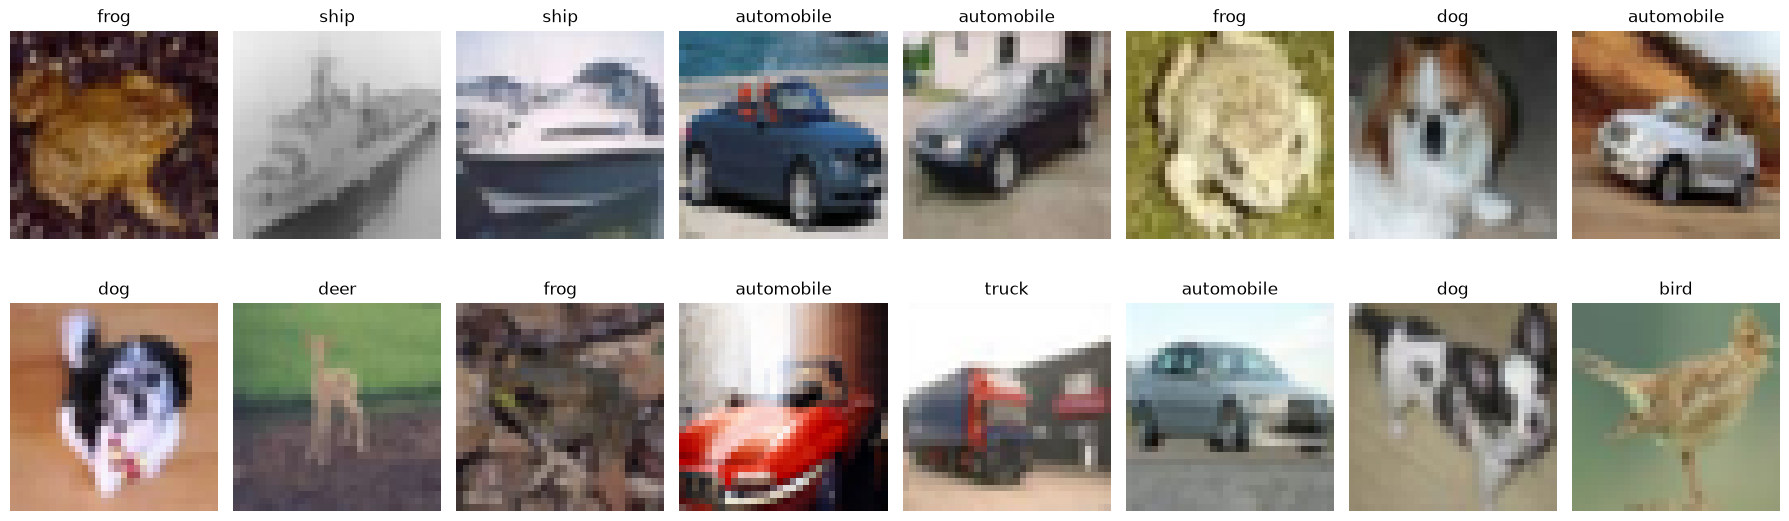

In [4]:
import matplotlib.pyplot as plt

sample_images, sample_labels = next(iter(trainloader))

fig, axes = plt.subplots(2, 8, figsize=(18, 6))

for index, axis in enumerate(axes.flat):

    image = sample_images[index].permute(1, 2, 0)

    image = image * 0.5 + 0.5

    image = torch.clamp(image, 0, 1)

    axis.imshow(image.numpy())
    axis.set_title(trainset.classes[sample_labels[index].item()])
    axis.axis("off")

plt.tight_layout()
plt.show()


### 데이터 증강

**데이터 증강(Data Augmentation)** 은 이미지의 정답은 유지하면서 위치, 방향, 크기 등을 조금씩 바꾸어 학습 데이터의 다양성을 높이는 방법이다.
새로운 이미지 파일을 저장하는 것이 아니라, Dataset에서 이미지를 꺼낼 때마다 무작위 변환을 적용한다.

- `RandomCrop`: 이미지 일부를 무작위 위치에서 잘라 물체의 위치가 조금씩 달라지게 한다.
- `RandomHorizontalFlip`: 이미지를 일정 확률로 좌우 반전한다.

이렇게 하면 모델이 특정 위치나 방향을 외우는 과적합을 줄이고, 새로운 이미지에 대한 성능을 높일 수 있다. 일반적으로 학습 데이터에만 적용하고 validation·test 데이터에는 적용하지 않는다. 원본 흐름을 유지하기 위해 아래에서는 효과만 확인하고 기본 학습 데이터에는 적용하지 않는다.

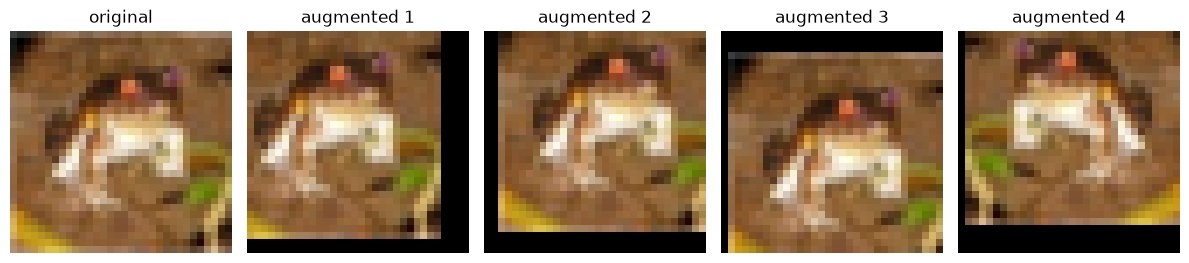

In [7]:
raw_image = trainset.data[0]

# 데이터 증강
augmentation = transforms.Compose([
    transforms.ToPILImage(), # 파이썬 인식 가능한 이미지로 변경
    # RandomCrop(32,padding=4)
    # 이미지에 4px 테두리(여백) 추가 후 32*32영역 무작위로 크롭
    transforms.RandomCrop(32,padding=4),

    transforms.RandomHorizontalFlip() # 확률적 수평 방향 반전(좌우반전)
])

# ----------------


fig, axes = plt.subplots(1, 5, figsize=(12, 3))

axes[0].imshow(raw_image)
axes[0].set_title("original")
axes[0].axis("off")

for index in range(1, 5):
    augmented_image = augmentation(raw_image)
    axes[index].imshow(augmented_image)
    axes[index].set_title(f"augmented {index}")
    axes[index].axis("off")

plt.tight_layout()
plt.show()


## 3. CIFAR-10 CNN 모델

FashionMNIST보다 색상과 배경이 다양한 CIFAR-10을 처리하기 위해 합성곱 층(Conv2d * 2) 블록을 세 번 사용한다.
각 블록은 `Conv2d → ReLU`를 두 번 적용해 RGB 픽셀에서 색상 변화, 경계선, 무늬, 질감 등의 특징을 충분히 추출한다.
그 뒤 `MaxPool2d`로 높이와 너비를 절반으로 줄인다.

- 첫 번째 블록: `(N, 3, 32, 32) → (N, 32, 16, 16)`
- 두 번째 블록: `(N, 32, 16, 16) → (N, 64, 8, 8)`
- 세 번째 블록: `(N, 64, 8, 8) → (N, 128, 4, 4)`
- Flatten: `(N, 128, 4, 4) → (N, 2048)`
- 완전연결층: 추출된 2,048개 특징을 종합해 클래스별 logits 10개를 만든다.

공간 크기는 `32 → 16 → 8 → 4`로 줄이고 채널 수는 `3 → 32 → 64 → 128`로 늘린다. 위치 정보는 압축하면서 물체를 구분할 수 있는 특징의 종류를 늘리는 흐름이다.

In [9]:
import torch
import torch.nn.functional as F
import torch.optim as optim
import torch.nn as nn

# nn.Module 상속
# 신경망 계층(Linear, Conv2d)의 가중치, 편향을 모델 파라미터로 자동등록
# -> 그래야 optim을 꺼내볼수있음
class CIFAR10_CNN(nn.Module):
    def __init__(self):
        super().__init__()

        # 1번 블록(신경망 계층 묶음)
        self.conv1_1 = nn.Conv2d(
            in_channels=3,
            out_channels=32,
            kernel_size=3, # 3*3 커널
            padding=1
        )# shape (n, 3,32,32) -> (n,32,32,32) in, out,가로 세로?
        # -> 특징 강조

        # 같은 형식 in/out -> 커널을 64개 쓴 효과 -> 특징이 더 뚜렷해짐
        self.conv1_2 = nn.Conv2d(
            in_channels=32,
            out_channels=32,
            kernel_size=3,
            padding=1
        )# 이전 합성곱의 출력을 그대로 새 합성곱에 입력 후, 같은 채널 /같은 크기로 다시 출력하면
        # 이미지의 특징이 더 뚜렷해진다

        # 2*2 MaxPool을 이용해서 높이,너비를절반으로 감소
        self.pool1 = nn.MaxPool2d(2)  # (n,32,32,32) -> (n,32,16,16)


        # 2번째 블록(채널 32->64, 크기 16*16 -> 8*8)
        self.conv2_1 = nn.Conv2d(32,64,kernel_size=3,padding=1)
        self.conv2_2 = nn.Conv2d(64,64,kernel_size=3,padding=1)
        self.pool2 = nn.MaxPool2d(2)

        # 3번째 블록(채널 32->64, 크기 8*8 -> 4*4)
        self.conv3_1 = nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.conv3_2 = nn.Conv2d(128,128,kernel_size=3,padding=1)
        self.pool3 = nn.MaxPool2d(2)
        # (n,128,4,4)

        # 평탄화(n,128,4,4) -> (n,2048)
        self.flatten = nn.Flatten()

        # Dropout : 학습데이터 중 일부를 0으로 만들어, 특정 feature에 지나치게 의존하는것을 방지
        # p=0.5 -> 전체 데이터 중 절반 X , 각 데이터가 50% 확률로 0으로 변경
        self.dropout1 = nn.Dropout(p=0.5)

        # 합성곱 계층의 결과를 받아 2048->300개까지 압축
        self.fc1 = nn.Linear(128*4*4, 300) # in, out


        # 한번더 dropout을 이용해과적합방지 진행
        self.dropout2 = nn.Dropout(p=0.3)
        # 300->10개 압축
        # cifar-10 클래스(정답)이 10개라서 출력도 10개
        self.fc2 = nn.Linear(300,10)

    # 순전파
    # x == 입력 이미지 n개(n은 batch size)
    def forward(self, x):
        x = F.relu(self.conv1_1(x)) # -> feature map(32개, 32*32)
        x = F.relu(self.conv1_2(x))
        x = self.pool1(x)

        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.pool2(x)

        x = F.relu(self.conv3_1(x))
        x = F.relu(self.conv3_2(x))
        x = self.pool3(x)

        # 추출된 feature map을 1차원 벡터로 평탄화 시킴
        x = self.flatten(x)

        # 완전 연결층(fc1,2에서 클래스 개수(10)만큼의 크기로 출력 압축)
        x = self.dropout1(x)
        x = F.relu(self.fc1(x)) # 2048->300
        # 다음 계층으로 전달하기 위해 활성화 필수

        x = self.dropout2(x)
        logits = self.fc2(x) # 300->10
        # 활성화 X -> 손실함수 CrossEntoropyLoss 이용 위해 logit 형태로 반환
        # 내부에 softmax 내장
        return logits

# 모델 생성
model = CIFAR10_CNN()
print(model)



CIFAR10_CNN(
  (conv1_1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv1_2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2_1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2_2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3_1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3_2): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (dropout1): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=2048, out_features=300, bias=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=300, out_features=10, bias=T

### logits shape와 확률 확인

모델은 이미지 한 장마다 10개의 logits를 출력한다. logit은 확률이 아니라 클래스별 원점수이므로 음수일 수 있고 합이 1일 필요도 없다.

- 학습할 때: `CrossEntropyLoss(logits, labels)`에 logits를 그대로 전달한다.
- 예측할 때: `argmax(dim=1)`로 가장 큰 logit의 클래스 index를 선택한다.
- 확률이 필요할 때: `softmax(logits, dim=1)`로 각 이미지의 10개 점수를 합이 1인 값으로 변환한다.

아직 학습 전이므로 아래 예측에는 의미가 없다. 이 셀의 목적은 모델의 입력·출력 shape와 계산 가능 여부를 학습 전에 점검하는 것이다.

In [10]:
dummy_images = torch.randn(4, 3, 32, 32)

model.eval() # 평가모드(DRopout 비활)
with torch.no_grad(): # 기울기계산 X -> 최적화 X
    logits = model(dummy_images)

    probabilities = torch.softmax(logits, dim=1)

print("logits shape:", logits.shape)
print("첫 이미지 logits:", logits[0])
print("첫 이미지 확률 합:", probabilities[0].sum().item())
print("예측 클래스 index:", logits[0].argmax().item())

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)
print("학습 가능한 파라미터 수:", trainable_parameters)


logits shape: torch.Size([4, 10])
첫 이미지 logits: tensor([-0.0341,  0.0486, -0.0475,  0.0482, -0.0194,  0.0086,  0.0061,  0.0400,
        -0.0271, -0.0263])
첫 이미지 확률 합: 0.9999998807907104
예측 클래스 index: 1
학습 가능한 파라미터 수: 904718


## 4. 학습·검증 데이터와 학습 도구 준비

공식 훈련 데이터 50,000장을 실제 학습용 train 85%와 학습 상태 점검용 validation 15%로 나눈다. 공식 test 데이터는 모델 선택에 사용하지 않고 마지막 최종 평가 때만 사용한다.

- **train**: `backward()`와 `optimizer.step()`을 실행해 가중치를 변경한다.
- **validation**: 가중치를 변경하지 않고 epoch마다 과적합과 일반화 상태를 확인한다.
- **test**: 학습과 모델 선택이 끝난 뒤 최종 성능을 한 번 평가한다.
- **device**: 모델과 입력 Tensor가 계산될 CPU·GPU·MPS 장치이다. 모델과 데이터는 같은 device에 있어야 한다.
- **CrossEntropyLoss**: `(N, 10)` logits와 `(N,)` 정수 클래스 index를 비교한다.
- **Adam**: `backward()`가 계산한 기울기를 이용해 모델의 가중치와 편향을 갱신한다.

앞에서 만든 `trainloader`는 데이터 확인용이고, 아래의 `train_loader`와 `val_loader`가 실제 학습·검증에 사용된다.

In [11]:
from torch.utils.data import random_split

train_size = int(0.85 * len(trainset))
val_size = len(trainset) - train_size

split_generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(
    trainset,
    [train_size, val_size],
    generator=split_generator,
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

model = model.to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

print("device:", device)
print("학습 데이터 수:", len(train_dataset))
print("검증 데이터 수:", len(val_dataset))
print("테스트 데이터 수:", len(testset))


device: cpu
학습 데이터 수: 42500
검증 데이터 수: 7500
테스트 데이터 수: 10000


## 이미 학습된 모델이 JOBLIB형태로 존재하면 읽어오기

In [21]:
from pathlib import Path
import joblib

MODELS_DIR = './models'
MODEL_NAME = 'cifar10_cnn.joblib'

model_path = Path(f'{MODELS_DIR}/{MODEL_NAME}')

if model_path.is_file():
    model = joblib.load(model_path)
    print('성공')
# 성공 시 아래 학습코드셀 실행x
else : print('실패')
#

### CNN 학습 루프

하나의 **epoch**는 train 데이터 전체를 한 번 학습하는 단위이다. 각 epoch 안에서 미니배치마다 다음 순서를 반복한다.

1. `model.train()`: Dropout을 사용하는 학습 모드로 전환한다.
2. `optimizer.zero_grad()`: 이전 미니배치의 기울기를 지운다.
3. `outputs = model(images)`: 현재 가중치로 logits를 계산한다.
4. `loss = criterion(outputs, labels)`: 예측과 정답의 차이를 하나의 손실값으로 계산한다.
5. `loss.backward()`: 손실을 각 파라미터로 미분해 기울기를 계산한다.
6. `optimizer.step()`: 기울기를 이용해 가중치와 편향을 갱신한다.

train 학습이 끝나면 `model.eval()`과 `torch.no_grad()`로 validation을 평가한다. validation에는 `backward()`와 `step()`이 없으므로 가중치가 바뀌지 않는다. `EPOCHS`만 바꾸면 짧은 실행 확인과 실제 학습 시간을 조절할 수 있다.

In [12]:
EPOCHS = 10

# 각 epoch별 지표를 저장할 dict
history = {
    'train_loss':[],
    'train_acc':[],
    'val_loss':[],
    'val_acc':[]
}

for epoch in range(EPOCHS):
    # 학습모드 설정
    model.train() # dropout 활성화

    # mini BATCH 별 loss와 acc를 누적할 변수
    # -> 마지막에 평균 계산에 사용
    train_loss_sum = 0.0
    train_correct = 0

    for images, labels in train_loader:

        # 입력, 정답, 모델 모두 같은 device로 설정되어야 연산 가능
        images = images.to(device)
        labels = labels.to(device)

        # 아전 최적화에 사용된 기울기 초기화
        optimizer.zero_grad()

        # 순전파
        outputs = model(images)

        # 손실함수
        loss = criterion(outputs, labels)

        # 오차역전파 # 손실을 줄이기 위한 기울기 계산(미분)
        loss.backward()

        # 최적화 (기울기 + lr 이용한 가중치, 편향 갱신)
        optimizer.step()

        train_loss_sum += loss.item() * images.size(0)

        # outputs에서 logit값이 가장 큰 index를 반환
        predictions = outputs.argmax(dim=1)
        train_correct += (predictions == labels).sum().item()
    # 학습끝

    # 검증
    model.eval() # 평가 모드
    val_loss_sum = 0.0
    val_correct = 0

        # 검증에서는 backward()와 optimizer.step()을 호출하지 않아 가중치를 바꾸지 않는다.
    # no_grad()는 연산 그래프를 만들지 않아 평가 속도를 높이고 메모리 사용량을 줄인다.
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss_sum += loss.item() * images.size(0)
            predictions = outputs.argmax(dim=1)
            val_correct += (predictions == labels).sum().item()

    # 누적값을 데이터 수로 나누어 epoch 전체의 평균 손실과 정확도를 계산한다.
    train_loss = train_loss_sum / len(train_loader.dataset)
    train_acc = train_correct / len(train_loader.dataset)
    val_loss = val_loss_sum / len(val_loader.dataset)
    val_acc = val_correct / len(val_loader.dataset)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch [{epoch + 1:02d}/{EPOCHS}] "
        f"train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
        f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}"
    )



Epoch [01/10] train_loss=1.6475, train_acc=0.3845, val_loss=1.2709, val_acc=0.5359
Epoch [02/10] train_loss=1.1843, train_acc=0.5711, val_loss=1.0945, val_acc=0.6128
Epoch [03/10] train_loss=0.9730, train_acc=0.6537, val_loss=0.8559, val_acc=0.7004
Epoch [04/10] train_loss=0.8397, train_acc=0.7062, val_loss=0.8664, val_acc=0.6955
Epoch [05/10] train_loss=0.7531, train_acc=0.7348, val_loss=0.7071, val_acc=0.7503
Epoch [06/10] train_loss=0.6850, train_acc=0.7600, val_loss=0.6852, val_acc=0.7587
Epoch [07/10] train_loss=0.6325, train_acc=0.7783, val_loss=0.6784, val_acc=0.7643
Epoch [08/10] train_loss=0.5843, train_acc=0.7943, val_loss=0.6502, val_acc=0.7721
Epoch [09/10] train_loss=0.5501, train_acc=0.8052, val_loss=0.6671, val_acc=0.7720
Epoch [10/10] train_loss=0.5136, train_acc=0.8198, val_loss=0.6056, val_acc=0.7871


## 5. 학습 곡선 확인

훈련·검증 손실과 정확도를 함께 그리면 학습 진행과 과적합 여부를 숫자 목록보다 쉽게 판단할 수 있다.

- train loss와 validation loss가 함께 감소하면 새로운 데이터에서도 학습이 진행되는 상태이다.
- train accuracy만 계속 상승하고 validation accuracy가 정체되면 학습 데이터를 외우는 과적합을 의심한다.
- train loss는 감소하지만 validation loss가 다시 상승하면 그 이전 epoch의 모델이 더 적절할 수 있다.
- loss가 크게 진동하거나 `NaN`이 되면 입력 값 범위, 학습률, label dtype과 logits shape를 확인한다.

정확도만 보지 않고 손실과 train·validation 사이의 간격을 함께 해석하는 것이 중요하다.

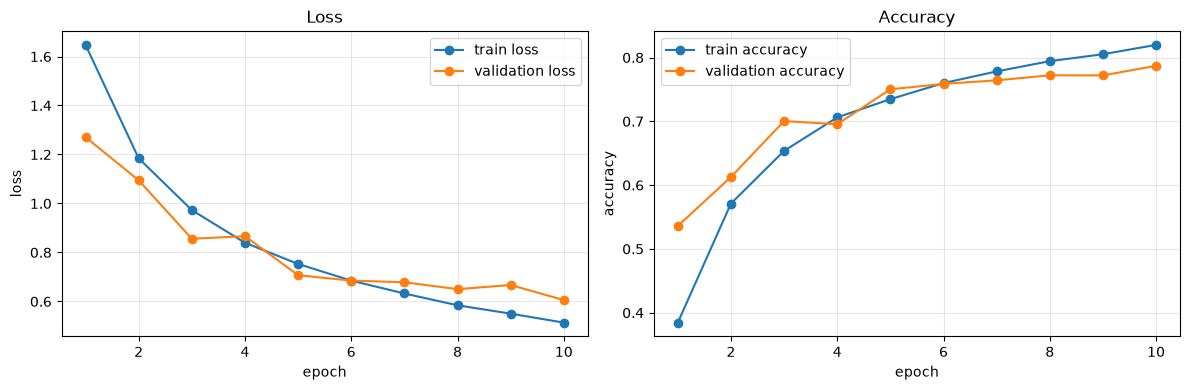

In [13]:
epoch_numbers = range(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epoch_numbers, history["train_loss"], marker="o", label="train loss")
plt.plot(epoch_numbers, history["val_loss"], marker="o", label="validation loss")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.grid(alpha=0.3)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epoch_numbers, history["train_acc"], marker="o", label="train accuracy")
plt.plot(epoch_numbers, history["val_acc"], marker="o", label="validation accuracy")
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


## 6. 테스트 데이터 최종 평가

테스트 데이터는 학습과 모델 선택에 사용하지 않은 데이터이다. 학습이 끝난 모델을 `eval()` 모드로 바꾸고, `torch.no_grad()` 안에서 평균 손실과 정확도를 계산한다.

- validation 성능: 학습 도중 epoch 수나 모델 설정을 판단하는 기준이다.
- test 성능: 모든 선택이 끝난 뒤 처음 보는 데이터에 대한 최종 일반화 성능이다.
- test 결과를 보고 반복해서 모델을 수정하면 test 데이터도 사실상 모델 선택에 사용한 것이 되므로 주의한다.

In [22]:
model.eval()
test_loss_sum = 0.0
test_correct = 0

with torch.no_grad():
    for images, labels in testloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        test_loss_sum += loss.item() * images.size(0)
        predictions = outputs.argmax(dim=1)
        test_correct += (predictions == labels).sum().item()

test_loss = test_loss_sum / len(testloader.dataset)
test_acc = test_correct / len(testloader.dataset)

print(f"test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")


test_loss=0.6342, test_acc=0.7876


## 핵심 정리

1. CIFAR-10 이미지는 `(N, 3, 32, 32)` 형태의 RGB Tensor로 모델에 입력된다.
2. `Normalize`는 RGB 채널의 값 범위를 조정해 학습을 안정화한다.
3. 합성곱층은 특징을 찾고, ReLU는 비선형성을 추가하며, pooling은 공간 크기를 줄인다.
4. 마지막 선형층은 10개 클래스의 **logits**를 출력한다.
5. `CrossEntropyLoss`에는 softmax를 적용하지 않은 logits와 정수 정답 index를 전달한다.
6. 학습은 `zero_grad → forward → loss → backward → step` 순서로 진행한다.
7. validation은 학습 상태를 점검하고, test는 최종 일반화 성능을 평가한다.

## 학습된 모델 내보내기(joblib)

In [19]:
import joblib
import copy
MODELS_DIR = './models'
MODEL_NAME = 'cifar10_cnn.joblib'


model_path =  MODELS_DIR+'/'+MODEL_NAME
# 모델의 모든 device를 cpu로 변경
model_to_save = copy.deepcopy(model).to('cpu')

model_to_save.eval()
joblib.dump(model_to_save, f'{MODELS_DIR}/{MODEL_NAME}')



['./models/cifar10_cnn.joblib']